In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px
%matplotlib inline

sd = pd.read_csv("data/student_habits_performance.csv")

In [2]:
def convert_to_letter_grade(score):
    if score >= 80:
        return 'A'
    elif score >= 70:
        return 'B'
    elif score >= 60:
        return 'C'
    elif score >= 50:
        return 'D'
    else:
        return 'F'

# Create 'grade' attribute
sd['grade'] = sd['exam_score'].apply(convert_to_letter_grade)

In [3]:
print(sd['grade'].unique())
grade_counts = sd['grade'].value_counts().sort_index()
print(grade_counts)

['D' 'A' 'F' 'C' 'B']
grade
A    277
B    234
C    209
D    149
F    131
Name: count, dtype: int64


In [4]:
sd['risk_status'] = sd['grade'].apply(lambda x: 'AtRisk' if x in ['D', 'F'] else 'NotAtRisk')

In [5]:
# Separate the target variable (risk_status) from the feature set
sd_y = sd['risk_status']
sd_X = sd[sd.columns.difference(['risk_status'])]

['age', 'attendance_percentage', 'diet_quality', 'exercise_frequency', 'extracurricular_participation', 'gender', 'internet_quality', 'mental_health_rating', 'netflix_hours', 'parental_education_level', 'part_time_job', 'sleep_hours', 'social_media_hours', 'study_hours_per_day', 'media_usage_hours_pca']
15
Best parameters found: {'ccp_alpha': 0.006731623306267057, 'criterion': 'entropy', 'max_depth': 6, 'min_impurity_decrease': 0.005, 'min_samples_leaf': 6, 'min_samples_split': 8, 'splitter': 'best'}
Mean Accuracy is 89.59 +/- 1.04
Mean Precision is 89.87 +/- 0.94
Mean Recall is 89.59 +/- 1.05
Mean F-score is 89.57 +/- 1.05
              precision    recall  f1-score   support

      AtRisk       0.75      0.84      0.79        56
   NotAtRisk       0.93      0.89      0.91       144

    accuracy                           0.88       200
   macro avg       0.84      0.86      0.85       200
weighted avg       0.88      0.88      0.88       200



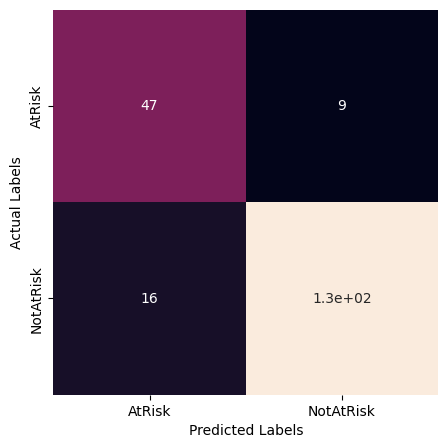

In [10]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from feature_engine.selection import SmartCorrelatedSelection
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from feature_engine.discretisation import DecisionTreeDiscretiser
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV, StratifiedKFold
from scipy.stats import uniform
import adsa_utils as ad

# Apply PCA on the original numerical data (social_media_hours, netflix_hours)
sd_XX = sd_X.copy()
pca = PCA(n_components=1)
sd_XX['media_usage_hours_pca'] = pca.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])

# Remove the proxy columns to avoid data leakage
sd_XX.drop(columns=['student_id', 'exam_score', 'grade'], inplace=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43, stratify=sd_y
)

# Better discretization settings: more robust grid
dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 4, 5, 6], 'ccp_alpha': [0.0, 0.005, 0.01]}
)

# Apply discretization
X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned = dt_binner.transform(X_test)
X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)
y_train = pd.Series(y_train)

# Process categorical columns: impute + ordinal encode
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)

# BorderlineSMOTE with improved k_neighbors
smote = BorderlineSMOTE(random_state=43, k_neighbors=5, m_neighbors=10)
#smote = SMOTE(random_state=43)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=cat_cols)
X_test = pd.DataFrame(scaler.transform(X_test), columns=cat_cols)

# Feature selection
selector_estimator = DecisionTreeClassifier(max_depth=7, min_samples_split=4,
                                            min_samples_leaf=10, ccp_alpha=0.007,
                                            random_state=43)
sfm = SelectFromModel(estimator=selector_estimator, threshold='median')
X_train_selected = sfm.fit_transform(X_train, y_train)
X_test_selected = sfm.transform(X_test)
selected_features = [cat_cols[index] for index in sfm.get_support(indices=True)]
X_train = pd.DataFrame(X_train_selected, columns=selected_features)
X_test = pd.DataFrame(X_test_selected, columns=selected_features)

print(selected_features)
print(len(selected_features))
# Cross-validation setup
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

# Extended search space for better tuning
params_dist = {
    'splitter': ['best'],
    'criterion': ['gini', 'entropy'],
    'max_depth': range(5, 7),
    'min_impurity_decrease': np.linspace(0.005, 0.05, 10),
    'min_samples_leaf': range(4, 16, 2),
    'min_samples_split': range(4, 12, 2),
    'ccp_alpha': uniform(loc=0.005, scale=0.004)
}
clf = DecisionTreeClassifier(random_state=43)
random_search = RandomizedSearchCV(
    clf,
    param_distributions=params_dist,
    n_iter=300,
    cv=stratified_cv,
    random_state=43,
    n_jobs=-1,
    scoring='accuracy'
)
random_search.fit(X_train, y_train)

# Evaluate best classifier
print(f'Best parameters found: {random_search.best_params_}')
best_clf = random_search.best_estimator_

# Evaluation
ad.cross_validation_avg_scores(X_train, y_train, best_clf, cv_=5, print_dict=False)
y_pred = best_clf.predict(X_test)
print(ad.classification_report(y_test, y_pred))
ad.plot_save_confusion_matrix(y_test, y_pred, "confusion_matrix_dt")

In [7]:
best_clf.get_depth(), best_clf.get_n_leaves()

(6, 19)

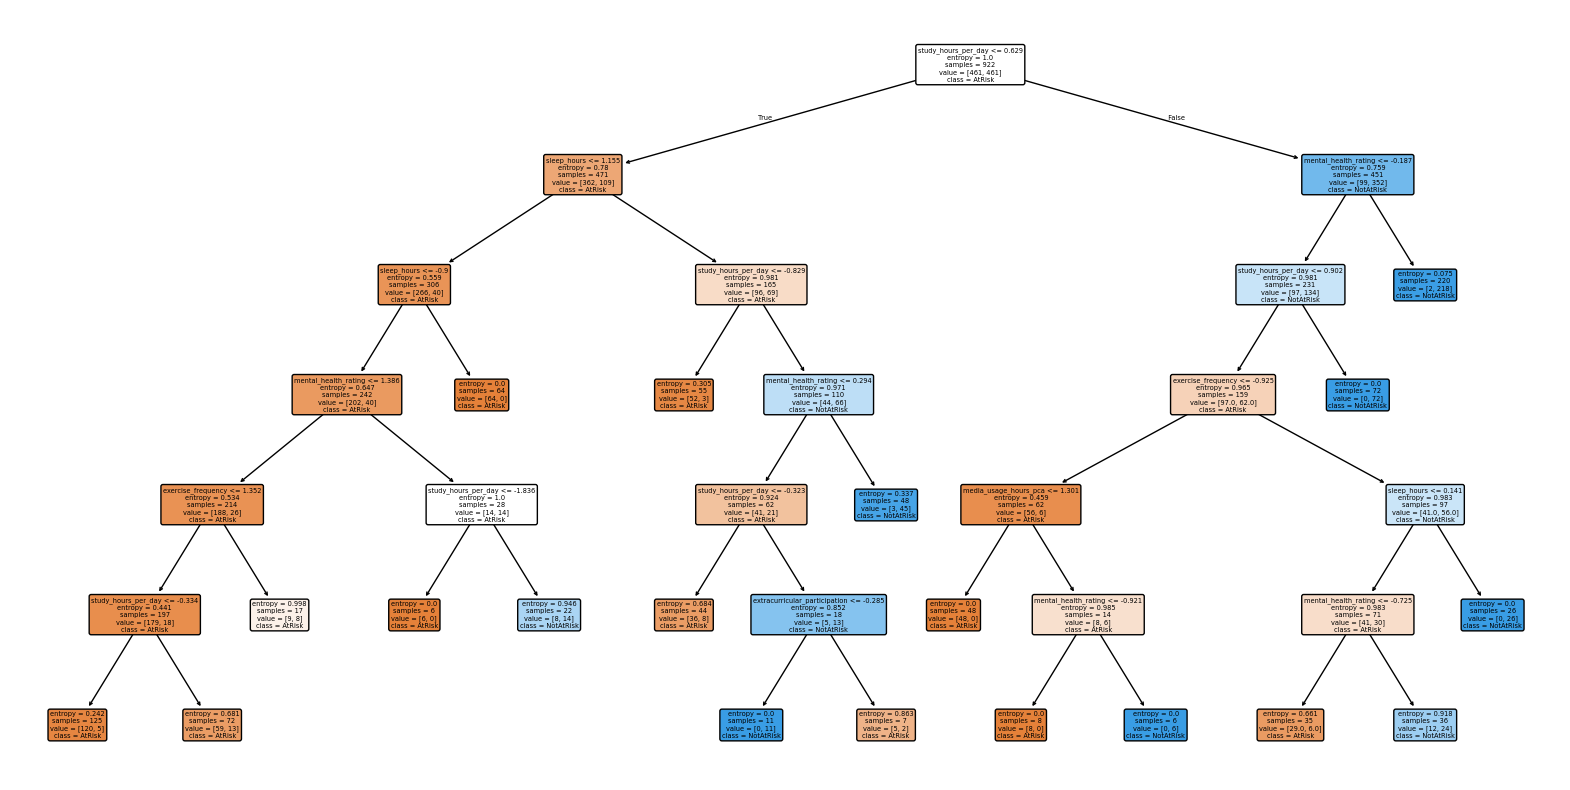

In [8]:
# Visualize the pruned decision tree
plt.figure(figsize=(20, 10))  # Adjust the size if necessary
plot_tree(
    best_clf, 
    filled=True, 
    feature_names=X_train.columns, 
    class_names=best_clf.classes_.astype(str),  # Ensure class names are in string format
    rounded=True
)
plt.show()

### **1. Overall Performance**
- **Random Forest**:
  - **Accuracy**: 90%
  - **Macro avg F1-score**: 87%
  - **Weighted avg F1-score**: 90%
  - **AUC**: **0.95**
  
- **XGBoost**:
  - **Accuracy**: 93%
  - **Macro avg F1-score**: 90%
  - **Weighted avg F1-score**: 92%
  - **AUC**: **0.96**

**Takeaway**:  
✅ XGBoost *slightly outperforms* Random Forest **across the board** — higher accuracy, better precision/recall balance, and a slightly better AUC.  
✅ The difference is small but **consistent** — suggesting XGBoost captures the patterns in your data a little more effectively.

---

### **2. Class-wise Analysis**
- For the **AtRisk** class (your probably minority class):
  - Random Forest has *lower precision* (0.77) but *higher recall* (0.84).
  - XGBoost boosts both **precision** (0.86) and **maintains** recall (0.84).
  
- For the **NotAtRisk** class:
  - Random Forest has strong precision and recall (~0.91).
  - XGBoost slightly improves both (~0.95), leading to better balance.

**Takeaway**:  
✅ XGBoost **helps more** with detecting "AtRisk" students correctly without sacrificing "NotAtRisk" accuracy.  
✅ This makes it better **especially in sensitive settings** like education or healthcare, where catching true positives ("AtRisk") matters a lot.

---

### **3. AUC Commentary**
- **AUC 0.95 (Random Forest)** vs **0.96 (XGBoost)** — **both are excellent** (typically, anything >0.9 is considered *outstanding*).
- XGBoost's curve is likely *slightly steeper* early on (i.e., at low false positive rates), meaning it does a better job distinguishing the two classes at earlier thresholds.
- **Real meaning**: If you were to vary the classification threshold (not just 0.5), XGBoost would *consistently outperform* Random Forest in identifying the correct class.

---

### **4. Practical Conclusion**
- If you just needed a *good model*, **either one is fine**.
- If you want to **maximize correct detection of "AtRisk" students**, **XGBoost is preferable**.
- If interpretability and simplicity matter a lot, Random Forest might be a little easier to explain — but XGBoost’s performance edge might justify the extra complexity.

---

### ✨ **Summary in one sentence:**
> "**Both models perform excellently, but XGBoost shows slightly better precision, recall, and AUC — making it the preferred choice, especially for sensitive prediction tasks like identifying 'AtRisk' students.**"

